In [1]:
import numpy as np

data = np.load('data_lunar_mesh_ex.npy', allow_pickle=True)
print(data.shape)

lidar = np.array(data[:,:, 10:], dtype=np.float32)

# making sure that correctly reading lidar
print(lidar.shape)
lidar = lidar.reshape(lidar.shape[0], lidar.shape[1], int(lidar.shape[2]/3), 3)
print(lidar.shape)
print(lidar[1][0])

(889, 19, 310)
(889, 19, 300)
(889, 19, 100, 3)
[[inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf i

(16891,)


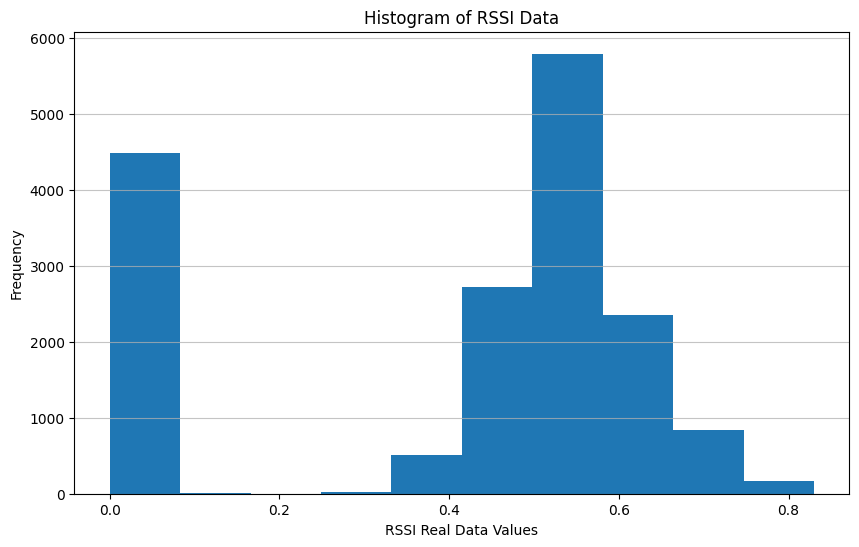

In [2]:

rsi_real = data[:, :, 0].flatten()
print(rsi_real.shape)

import matplotlib.pyplot as plt

# Compute the histogram
hist, bin_edges = np.histogram(rsi_real, bins=10)

# Plot the histogram using bar
plt.figure(figsize=(10, 6))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, hist, width=np.diff(bin_edges), align='center')
plt.title('Histogram of RSSI Data')
plt.xlabel('RSSI Real Data Values')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [5]:
## Converting lidar to range data
#HAVE TO TRY RUNNING THIS ON UNNORMALIZED LIDAR DATA
import math

print(data.shape)

def distance(x, y):
    dist = (x[0]-y[0])**2 + (x[1]-y[1])**2 + (x[2]-y[2])**2
    # print(dist)
    if math.isinf(dist):
       dist = 0 
    return math.sqrt(dist)

def getRange(position, lidar):
    range_data = []
    for i in range(len(lidar)):
        dist = distance(position, lidar[i])
        range_data.append(dist)
        
    return np.array(range_data)

lidar_range = np.empty((0, 100))
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        position = [data[i, j, 7], data[i, j, 8], data[i, j, 9]]
        range_data = getRange(position, data[i, j, 10:].reshape(100, 3)).reshape(1, -1)
        lidar_range = np.concatenate((lidar_range, range_data), axis=0)

lidar_range = lidar_range.reshape(data.shape[0], data.shape[1], -1)

(889, 19, 310)


In [6]:
print(lidar_range.shape)
print(lidar_range[1][0])
# print(lidar[1][0])
# print(lidar_range[1])

(889, 19, 100)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [7]:
trajectories = np.load('trajectories_1000.npy')
print(trajectories.shape)

def max_lidar_distance(points, loc, max_dist):
    updated_PC = []
    for i in range(len(points)):
        if (np.linalg.norm(loc - points[i]) <= max_dist):
            updated_PC.append(points[i])
        else:
            updated_PC.append(np.array([float('inf'), float('inf'), float('inf')]))
    return np.array(updated_PC)    

def normalize_pc(points):
    # data that does not include all the infinites (just for calculating the mean and furthest_distance)
    cleaned_data = np.array(points[np.where(points[:, 0] != float('inf'))], dtype="float32")
    if (len(cleaned_data) == 0):
        return points

    centroid = np.mean(cleaned_data, axis=0)
    points -= centroid
    furthest_distance = np.max(np.sqrt(np.sum(abs(cleaned_data)**2,axis=-1)))
    points /= furthest_distance
    
    return np.array(points, dtype=np.float32)

(889, 20, 3)


In [8]:
# SIMPLE LIDAR MODEL THAT USES LIDAR RANGE DATA
#https://medium.com/we-talk-data/pytorchs-sequential-3974f27c714e 

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

# print(lidar_range[1][0])
lidar_range = lidar_range.reshape(-1, 100)
print(lidar_range.shape)

dataset = torch.tensor(lidar_range, dtype=torch.float32)
print(dataset.shape)

train_size = int(0.7 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=200, shuffle=False)

(16891, 100)
torch.Size([16891, 100])


In [9]:
class FCN(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_sizes
        self.output_size = output_size
        
        self.steps = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[1], output_size)
        )

    def forward(self, x):
        x = self.steps(x)
        return x

num_epochs = 1000
model_lidar_range = FCN(input_size = 100, hidden_sizes=[100, 100], output_size=100)
optimizer = torch.optim.Adam(model_lidar_range.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(num_epochs):
    model_lidar_range.train()
    for input_seq in train_loader:
        input_seq = input_seq[:, :100]
        input_seq = torch.nan_to_num(input_seq, nan=1e-6, posinf=1e-6, neginf=1e-6)

        output = model_lidar_range(input_seq)
        target_val = input_seq

        loss = criterion(output, target_val)  # shape: [batch, 100]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [10]:
print(lidar_range[20])
model_lidar_range(torch.tensor(lidar_range[20], dtype=torch.float32))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


tensor([ 1.7148e-03,  3.7427e-03,  7.8847e-04,  6.9871e-04,  2.5320e-03,
         2.4820e-03,  6.5519e-04,  2.8395e-03, -1.0419e-03,  4.2351e-04,
        -8.8099e-04, -7.5005e-04,  2.8332e-03,  3.4833e-04,  1.2850e-04,
        -1.2787e-04,  9.6757e-04,  6.1288e-04,  1.9083e-03,  1.8662e-03,
         1.0474e-03,  9.9557e-04,  1.0101e-04,  2.4661e-03,  2.1989e-03,
        -2.2648e-03,  4.1007e-03,  1.6257e-03,  1.5392e-03, -3.0111e-03,
        -3.4412e-03,  1.3307e-03, -2.2240e-03, -1.0390e-03, -7.7401e-04,
        -1.2544e-03,  1.1525e-03,  2.6112e-03,  4.3778e-04, -4.1701e-05,
         4.6348e-04,  6.0881e-04, -1.5149e-03, -1.4425e-03, -9.5391e-04,
         4.1948e-04, -2.0722e-04, -5.2179e-04, -1.9399e-03, -2.0940e-03,
        -4.1480e-03, -4.0369e-03, -2.1226e-03, -1.0169e-03, -3.0823e-03,
        -6.6701e-04, -1.7076e-03, -1.4691e-03,  2.1389e-03, -3.3629e-03,
        -3.5070e-03, -4.0168e-03, -3.5312e-03, -3.1455e-03, -3.3379e-03,
        -2.2437e-03, -2.0735e-03,  1.1073e-03, -6.0

In [20]:
## Autoencoder, compression
# https://www.geeksforgeeks.org/auto-encoders/

dataset = torch.tensor(lidar_range, dtype=torch.float32)
dataset = dataset.reshape(-1, 19, 100)
print(dataset.shape)

train_size = int(0.7 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=200, shuffle=False)

class AutoEncoder(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(AutoEncoder, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_sizes
        self.output_size = output_size
        
        self.encoder = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[1], output_size)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(output_size, hidden_sizes[1]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[1], hidden_sizes[0]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[0], input_size),
        )
    
    def forward(self, input_data):
        encoded = self.encoder(input_data)
        decoded = self.decoder(encoded)
        return encoded, decoded



torch.Size([889, 19, 100])


Epoch 100/500, Loss: 0.011288
Epoch 200/500, Loss: 0.020414
Epoch 300/500, Loss: 0.036956
Epoch 400/500, Loss: 0.007678
Epoch 500/500, Loss: 0.000003


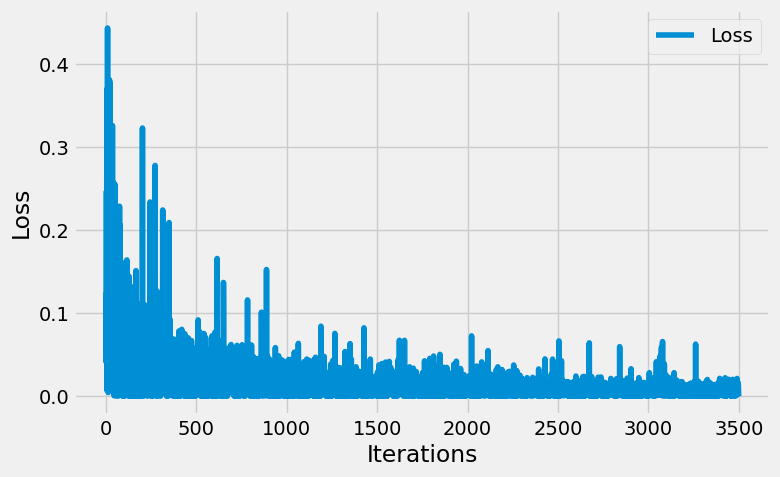

In [21]:
num_epochs = 500
model_lidar_encoder = AutoEncoder(input_size = 100, hidden_sizes=[50, 25], output_size=5)
optimizer = torch.optim.Adam(model_lidar_encoder.parameters(), lr=1e-3)
criterion = nn.MSELoss()

outputs = []
losses = []

for epoch in range(num_epochs):
    model_lidar_encoder.train()
        
    for input_seq in train_loader:
        input_seq = input_seq[:, :100]
        input_seq = torch.nan_to_num(input_seq, nan=1e-6, posinf=1e-6, neginf=1e-6)

        encoded, decoded = model_lidar_encoder(input_seq)
        target_val = input_seq

        loss = criterion(decoded, target_val)  # shape: [batch, 100]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
         
        
        losses.append(loss.item())
    
    # outputs.append((epoch, images, reconstructed))
    if ((epoch + 1) % 100) == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
### Test on actual model
# -----------------------------------------------------------------------------------------------------------------------------------------

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

num_epochs = 100

data = np.load("data_lunar_mesh_ex.npy", allow_pickle=True)
data = data.astype(np.float32)
print(f"Loaded data shape: {data.shape}")

total_traj = data.shape[0]
seq_len = data.shape[1] + 1


data = torch.tensor(data[:,:, :10].reshape(total_traj * (seq_len - 1), 10), dtype=torch.float32)
combined_data = data.reshape(total_traj, seq_len - 1, 10)
print(combined_data.shape)

# print(data.shape)
# lidar_data = model_lidar_range(torch.tensor(lidar_range, dtype=torch.float32))
lidar_data, decoded = model_lidar_encoder(torch.tensor(lidar_range, dtype=torch.float32))

# combined_data = torch.cat((data, lidar_data.detach()), 1).reshape(total_traj, (seq_len - 1), -1)
# without above line, OG model W/O lidar
combined_data.shape

Loaded data shape: (889, 19, 310)
torch.Size([889, 19, 10])


torch.Size([889, 19, 10])

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

# total_traj = 500
# seq_len = 20
# data = np.load("data_lunar_mesh_ex.npy")
# print(f"Loaded data shape: {data.shape}")
# data = data[:,:, :10].reshape(total_traj, seq_len - 1, 10) 

class TrajectoryDataset(torch.utils.data.Dataset):
    def __init__(self, data_tensor, predictions):
        self.data = data_tensor
        self.predictions = predictions

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        seq = self.data[idx]                 # shape (21, 10)
        # print(seq.shape[0])
        # print(seq.shape[0] - self.predictions)
        input_seq = seq[:seq.shape[0] - self.predictions]                 # shape (18, 10)
        target_values = seq[seq.shape[0] - self.predictions:]          # shape (3,) — 3 future values of feature[0]
        return input_seq, target_values

num_pred = 10
input_size = combined_data.shape[2]

# Wrap your tensor in the dataset
dataset = TrajectoryDataset(combined_data, num_pred)

# Split
train_size = int(0.7 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=200, shuffle=False)

class LSTMMultiStep(nn.Module):
    def __init__(self, input_size=input_size, hidden_size=64, num_layers=1, num_pred=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_pred)  # Predict 3 future values (1 feature)
        self.activation = nn.Sigmoid()

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        last_hidden = hn[-1]                 # shape: (batch, hidden_size)
        output = self.fc(last_hidden)        # shape: (batch, 3)
        output = self.activation(output)
        return output

print(dataset.data.shape)
input_seq, target_values = dataset.__getitem__(0)
print(input_seq.shape)
# print(dataset.__getitem__(0)[1].shape)


torch.Size([889, 19, 10])
torch.Size([9, 10])


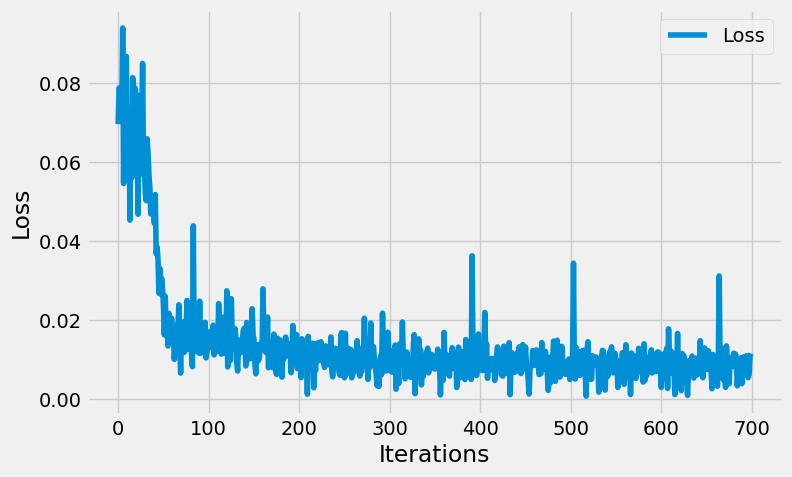

In [29]:
import matplotlib.pyplot as plt

model = LSTMMultiStep(input_size=input_size-3, num_pred=num_pred)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
losses = []

for epoch in range(num_epochs):
    model.train()
    for input_seq, target_val in train_loader:
        input_seq = torch.concatenate((input_seq[:, :, :7], input_seq[:, :, 10:]), axis=2)
        output = model(input_seq)
        loss = criterion(output, target_val[:,:,0]) # Add PINNs stuff here

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    # Optional test loop
    rssi_ground_truth = []
    rssi_predicted = []
    pos = []
    rssi_seq = []
    model.eval()
    with torch.no_grad():
        test_losses = []
        for input_seq, target_val in test_loader:
            # pos.append(input_seq[:, -1, 7:])
            pos.append(target_val[:,:,7:10])
            input_seq = torch.concatenate((input_seq[:, :, :7], input_seq[:, :, 10:]), axis=2)
            test_output = model(input_seq)
            rssi_ground_truth.append(target_val[:,:,0].numpy())
            rssi_seq.append(np.concatenate([input_seq.numpy()[:, :, 0], target_val[:,:,0].numpy()], axis=1))
            rssi_predicted.append(test_output.numpy())
            test_loss = criterion(test_output, target_val[:,:,0])
            test_losses.append(test_loss.item())
        avg_test_loss = sum(test_losses) / len(test_losses)


torch.save(model.state_dict(), "NASA_DCGR.pt")

plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [30]:
import trimesh
mesh = trimesh.load_mesh("models/lunar_mesh_ex.ply")
# mesh = trimesh.load_mesh("models/canyon.ply")
import numpy as np
import matplotlib.pyplot as plt

print(len(rssi_seq))
rssi_seq_start = np.array(rssi_seq[0])
print(rssi_seq_start[:,:9].shape)

# Naive prediction
naive_pred = rssi_seq_start[:, 8:9].repeat(10, 1)
print(naive_pred.shape)

# Linear regression
x_fit = np.arange(9)
x_pred = np.arange(9, 19)

# Fit degree-1 polynomial (line)
coeffs = np.polyfit(x_fit, rssi_seq_start[:, :9].T, deg=1)  # shape (2, 995)

# Evaluate line at x_pred
x_pred_powers = np.vstack([x_pred, np.ones_like(x_pred)])  # shape (2, 10)
linear_pred = coeffs.T @ x_pred_powers  # shape (995, 10)
print(linear_pred.shape)

# Cubic spline
from scipy.interpolate import CubicSpline
spline_preds = []

for seq in rssi_seq_start[:, :9]:
    cs = CubicSpline(x_fit, seq[:9], extrapolate=True)
    pred = cs(x_pred)
    spline_preds.append(pred)

spline_pred = np.stack(spline_preds)  # shape (995, 10)
print(spline_pred.shape)

# radius = 5.0  # small radius for visibility
# markers = []
# for rssis, poses in zip(predictions, pos[0]):
#     for rssi, pose in zip(rssis, poses):
#         marker = trimesh.creation.icosphere(radius=radius, color=[rssi, 0, (1 - rssi), 1])  # red color
#         marker.apply_translation(pose)
#         markers.append(marker)

# scene = trimesh.Scene()
# scene.add_geometry(markers)
# scene.add_geometry(mesh)
# scene.show()

2
(200, 9)
(200, 10)
(200, 10)
(200, 10)


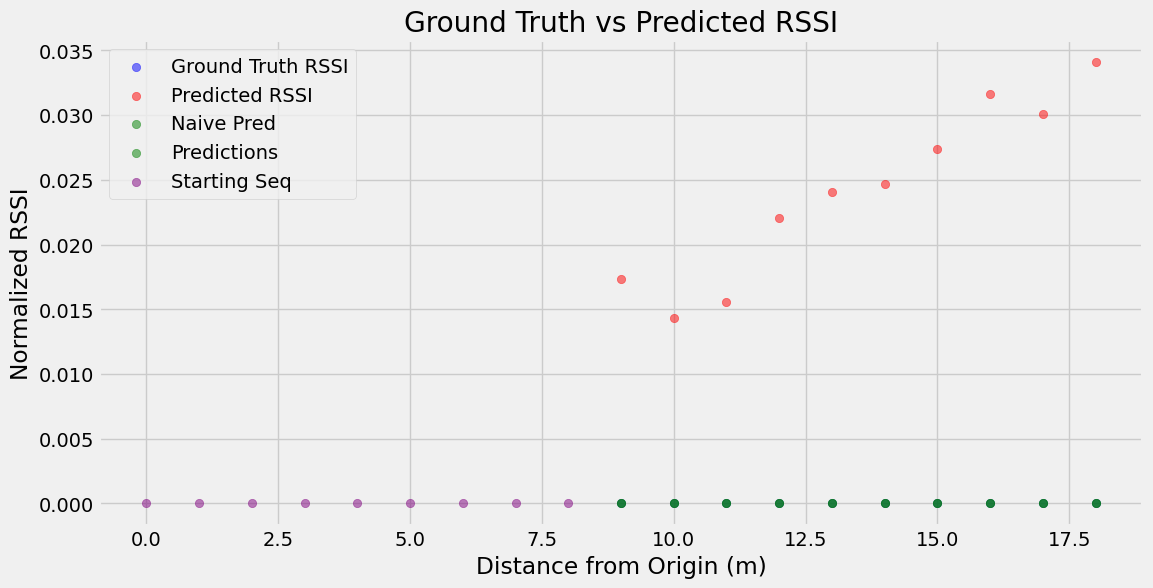

RNN Predictions
Mean Squared Error (MSE): 0.0075
Mean Absolute Error (MAE): 0.0404
Linear Regression Predictions
Mean Squared Error (MSE): 0.0098
Mean Absolute Error (MAE): 0.0312
torch.Size([2000, 3])
(2000,)


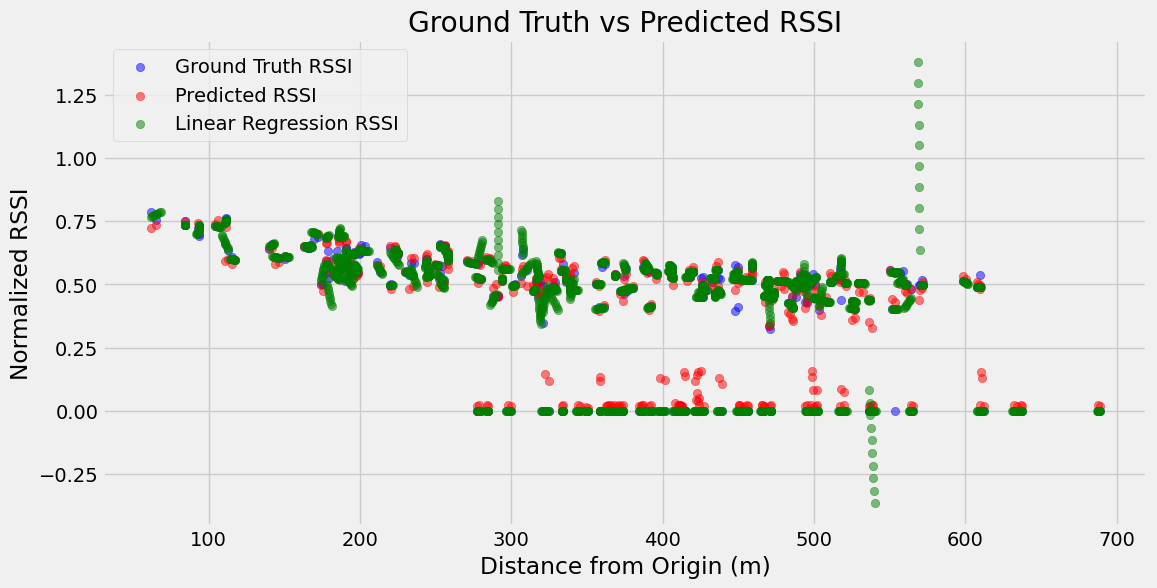

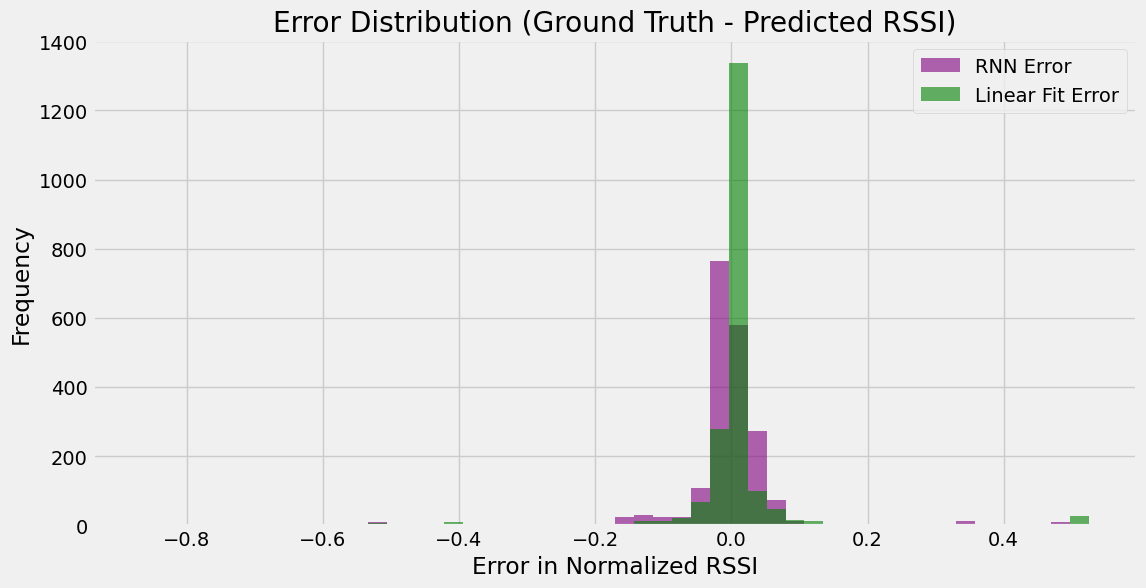

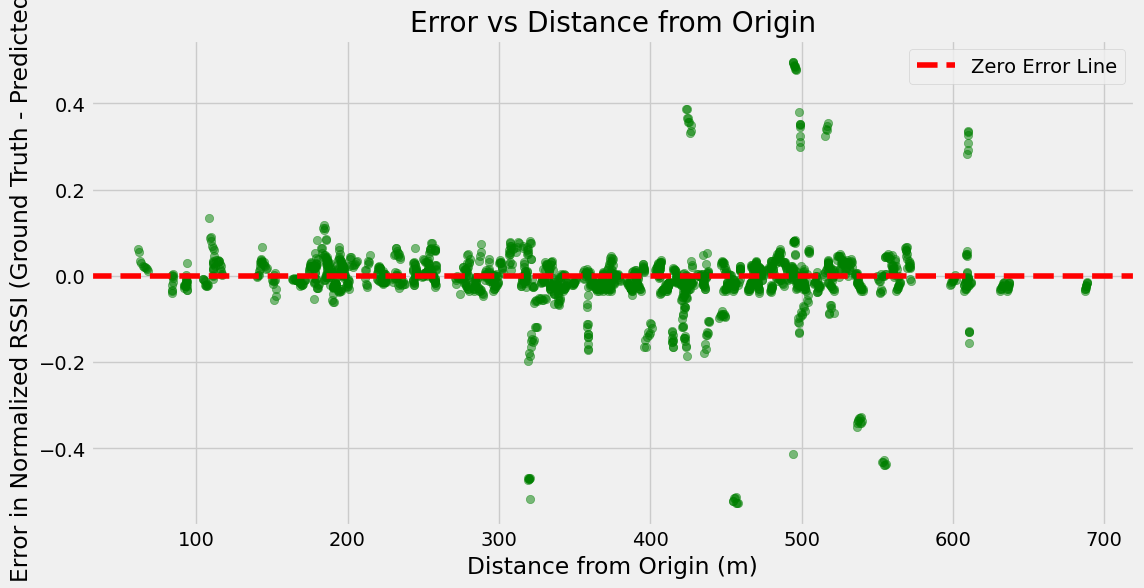

In [31]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Compute MSE (Lower is better)

mse = mean_squared_error(rssi_ground_truth[0], rssi_predicted[0])
mae = mean_absolute_error(rssi_ground_truth[0], rssi_predicted[0])


time = np.arange(0, 20)
index = 18
plt.figure(figsize=(12, 6))
plt.scatter(time[9:19], rssi_ground_truth[0][index, :], label='Ground Truth RSSI', color='blue', alpha=0.5)
plt.scatter(time[9:19], rssi_predicted[0][index, :], label='Predicted RSSI', color='red', alpha=0.5)
plt.scatter(time[9:19], naive_pred[index, :], label='Naive Pred', color='green', alpha=0.5)
plt.scatter(time[9:19], linear_pred[index, :], label='Predictions', color='green', alpha=0.5)
# plt.scatter(time[10:], spline_pred[index, :], label='Predictions', color='green', alpha=0.5)
plt.scatter(time[:9], rssi_seq_start[index,:9], label='Starting Seq', color='purple', alpha=0.5)
plt.title('Ground Truth vs Predicted RSSI')
plt.xlabel('Distance from Origin (m)')
plt.ylabel('Normalized RSSI')
plt.legend()
plt.grid(True)
plt.show()

#Unnormalize the data
from data_manipulations import denormalize
min_rss = -90
max_rss = 0

print(f"RNN Predictions")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

mse = mean_squared_error(rssi_ground_truth[0], linear_pred)
mae = mean_absolute_error(rssi_ground_truth[0], linear_pred)
print(f"Linear Regression Predictions")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

print(pos[0].reshape(-1, 3).shape)
print(rssi_ground_truth[0].reshape(-1).shape)

distance = torch.norm(pos[0].reshape(-1, 3), dim=1)
rssi_ground_truth_flat = np.array(rssi_ground_truth[0]).flatten()
rssi_predicted_flat = np.array(rssi_predicted[0]).flatten()

# rssi_ground_truth_flat = denormalize(rssi_ground_truth_flat, min_rss, max_rss)
# linear_pred = denormalize(linear_pred, min_rss, max_rss)
# rssi_predicted_flat = denormalize(rssi_predicted_flat, min_rss, max_rss)

# Plotting the ground truth vs predicted RSSI values
plt.figure(figsize=(12, 6))
plt.scatter(distance.numpy()[::5], rssi_ground_truth_flat[::5], label='Ground Truth RSSI', color='blue', alpha=0.5)
plt.scatter(distance.numpy()[::5], rssi_predicted_flat[::5], label='Predicted RSSI', color='red', alpha=0.5)
plt.scatter(distance.numpy()[:], np.array(linear_pred).flatten()[:], label='Linear Regression RSSI', color='green', alpha=0.5)
plt.title('Ground Truth vs Predicted RSSI')
plt.xlabel('Distance from Origin (m)')
plt.ylabel('Normalized RSSI')
plt.legend()
plt.grid(True)
plt.show()
# # Plotting the error distribution
# plt.figure(figsize=(12, 6))
# errors = np.array(rssi_ground_truth[0]).flatten() - np.array(rssi_predicted[0]).flatten()
# plt.hist(errors, bins=50, color='purple', alpha=0.7)
# errors_reg = np.array(rssi_ground_truth[0]).flatten() - linear_pred.flatten()
# plt.hist(errors_reg, bins=50, color='green', alpha=0.5)
# plt.title('Error Distribution (Ground Truth - Predicted RSSI)')
# plt.xlabel('Error in Normalized RSSI')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.show()
# Flatten and compute errors
errors_rnn = rssi_ground_truth_flat - rssi_predicted_flat
errors_linear = rssi_ground_truth_flat - linear_pred.flatten()
# 1. Find shared min/max
combined = np.concatenate([errors_rnn, errors_linear])
bin_edges = np.linspace(combined.min(), combined.max(), 51)  # 50 bins
# 2. Plot both with same bins
plt.figure(figsize=(12, 6))
plt.hist(errors_rnn, bins=bin_edges, color='purple', alpha=0.6, label='RNN Error')
plt.hist(errors_linear, bins=bin_edges, color='green', alpha=0.6, label='Linear Fit Error')
plt.title('Error Distribution (Ground Truth - Predicted RSSI)')
plt.xlabel('Error in Normalized RSSI')
plt.ylabel('Frequency')
plt.grid(True)
plt.legend()
plt.show()
# Plotting the error against distance
plt.figure(figsize=(12, 6))
plt.scatter(distance.numpy(), errors_rnn, color='green', alpha=0.5)
plt.title('Error vs Distance from Origin')
plt.xlabel('Distance from Origin (m)')
plt.ylabel('Error in Normalized RSSI (Ground Truth - Predicted)')
plt.axhline(0, color='red', linestyle='--', label='Zero Error Line')
plt.legend()
plt.grid(True)
plt.show()

# RNN Predictions
# Mean Squared Error (MSE): 0.0397
# Mean Absolute Error (MAE): 0.1274
# Linear Regression Predictions
# Mean Squared Error (MSE): 0.1162
# Mean Absolute Error (MAE): 0.1790

# RNN Predictions
# Mean Squared Error (MSE): 0.0264
# Mean Absolute Error (MAE): 0.1118
# Linear Regression Predictions
# Mean Squared Error (MSE): 0.0940
# Mean Absolute Error (MAE): 0.1528